In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent.parent
DATA_DIR = PROJECT_ROOT / "data"

## Data cleanning

In [8]:
final_lstm_predictions = pd.read_csv(DATA_DIR / "final_lstm_predictions_all_players.csv")

# fix possible Nikola spelling inside current dataframe
final_lstm_predictions["PLAYER_NAME"] = final_lstm_predictions["PLAYER_NAME"].replace({
    "Nikola Vu?evi?": "Nikola Vucevic",
    "Nikola Vučević": "Nikola Vucevic"
})

# keep the two players and show all columns
selected_players = ["Trae Young", "Nikola Vucevic"]
df_selected = final_lstm_predictions[final_lstm_predictions["PLAYER_NAME"].isin(selected_players)].copy()

for player in selected_players:
    print("\n" + "="*60)
    print(player)
    print("="*60)
    print(final_lstm_predictions[final_lstm_predictions["PLAYER_NAME"] == player].T)



Trae Young
                          0
PLAYER_NAME      Trae Young
PLAYER_ID           1629027
Train_Test             Test
actual_class        Sleeper
predicted_class     Sleeper
prob_Bust          0.000188
prob_Neutral       0.002685
prob_Sleeper       0.997127
label_known               1
is_correct              1.0
max_pred_prob      0.997127
confidence             High

Nikola Vucevic
                             18
PLAYER_NAME      Nikola Vucevic
PLAYER_ID                202696
Train_Test                 Test
actual_class            Neutral
predicted_class         Sleeper
prob_Bust              0.008924
prob_Neutral           0.039618
prob_Sleeper           0.951458
label_known                   1
is_correct                  0.0
max_pred_prob          0.951458
confidence                 High


In [9]:
# read file
df = pd.read_csv(DATA_DIR / "all_player_stats_1999-2025.csv")

# mapping for bad Excel-style season values
season_fix_map = {
    "Jan-00": "2000-01",
    "Feb-01": "2001-02",
    "Mar-02": "2002-03",
    "Apr-03": "2003-04",
    "May-04": "2004-05",
    "Jun-05": "2005-06",
    "Jul-06": "2006-07",
    "Aug-07": "2007-08",
    "Sep-08": "2008-09",
    "Oct-09": "2009-10",
    "Nov-10": "2010-11",
    "Dec-11": "2011-12"
}

# clean season column
df["season"] = df["season"].replace(season_fix_map)

# create year column from the first 4 digits of season
df["year"] = df["season"].str.extract(r"^(\d{4})-").astype(int)

# optional: move year next to season
cols = df.columns.tolist()
season_idx = cols.index("season")
cols.insert(season_idx + 1, cols.pop(cols.index("year")))
df = df[cols]

In [10]:
# -----------------------------
# 2. Basic playing-time filter
# -----------------------------
# Keep only seasons where player actually played enough
df_clean = df[(df["GP"] > 20) & (df["MIN"] > 10)].copy()

# -----------------------------
# 4. Remove only rows with missing values
# -----------------------------
# This removes only the player-year row that has missing data
df_clean = df_clean.dropna().copy()

print("\nShape after dropping missing rows:")
print(df_clean.shape)

# -----------------------------
# 5. Count number of seasons per player
# -----------------------------
# assuming player name column is PLAYER_NAME
player_season_counts = (
    df_clean.groupby("PLAYER_NAME")
    .size()
    .reset_index(name="n_seasons")
)

# merge season count back to dataframe
df_clean = df_clean.merge(player_season_counts, on="PLAYER_NAME", how="left")


Shape after dropping missing rows:
(10892, 39)


# 2. Skills radar chart

**Goal: Given the player’s predicted class (Bust / Neutral / Sleeper), how does that player’s early-career basketball profile compare with the average profile of players in that same class?**

This cell takes each player’s first 4 cleaned seasons, computes six basketball skill dimensions, converts them into 0–100 percentile scores, and then draws radar charts comparing each selected player to the average skill profile of the class predicted by the model.

Example:
1. *Trae Young → compare his first-4-year profile to the average Sleeper*
2. *Nikola Vucevic → compare his first-4-year profile to the average Neutral*

**Percentile Scaling**

Percentile scaling converts each raw skill value into a 0–100 relative score by ranking the player against the full eligible player cohort. A higher percentile means the player is stronger than more players on that dimension. This makes different basketball variables comparable on the same radar chart, even though their original units are very different.

Player scaling: compare the player to the full player cohort

Class average scaling: average the already-scaled players in that class

**Skill dimensions**

The 6 radar dimensions are:

1. Scoring = PTS
2. Shooting = (FG_PCT+FG3_PCT+FT_PCT)/3
3. Playmaking = AST
4. Rebounding = REB
5. Defense = STL+BLK
6. Ball Security = AST/TOV

**Then for each selected player:**
1. blue line = player
2. dashed gray line = average of that player’s predicted class


# Introduction

**Trace Young** is a premier NBA point guard known for elite playmaking, deep three-point range, and high-scoring capability. Drafted 5th overall in 2018, the multi-time All-Star led the Atlanta Hawks to the 2021 Eastern Conference Finals, cementing his reputation as a franchise cornerstone before joining the Washington Wizards in 2026. 

**Nikola Vučević** is a 6'11" veteran Montenegrin-Swiss center drafted 16th overall by Philadelphia in 2011 out of USC. Known for his exceptional consistency, consistent double-double ability, and skilled offensive game (post-up/pick-and-pop), he is a 2x NBA All-Star who has anchored the frontcourts of the 76ers, Magic, Bulls, and Celtics during his 12+ season career. 

This report will use Trace Young and Nikola Vučević as the control group,

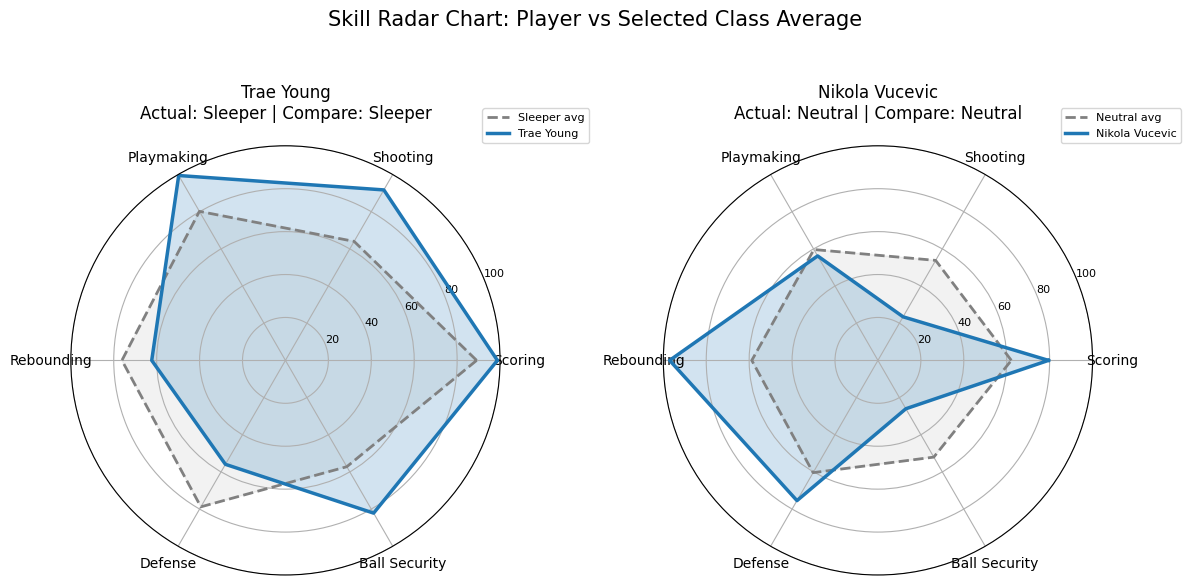

In [11]:
# =========================================================
# 1. Use cleaned season data and final prediction table
# =========================================================
season_df = df_clean.copy()
pred_df = final_lstm_predictions.copy()

# fix possible name issue
name_fix = {
    "Nikola Vu?evi?": "Nikola Vucevic",
    "Nikola Vučević": "Nikola Vucevic"
}
season_df["PLAYER_NAME"] = season_df["PLAYER_NAME"].replace(name_fix)
pred_df["PLAYER_NAME"] = pred_df["PLAYER_NAME"].replace(name_fix)

# =========================================================
# 2. Rebuild career order after cleaning
# =========================================================
season_df = season_df.sort_values(["PLAYER_NAME", "year"]).reset_index(drop=True)
season_df["career_year"] = season_df.groupby("PLAYER_NAME").cumcount() + 1

# keep only players with at least 4 cleaned seasons
player_counts = season_df.groupby("PLAYER_NAME").size().reset_index(name="n_seasons")
valid_players = player_counts.loc[player_counts["n_seasons"] >= 4, "PLAYER_NAME"]
season_df = season_df[season_df["PLAYER_NAME"].isin(valid_players)].copy()

# keep first 4 cleaned seasons only
season_1to4 = season_df[season_df["career_year"].between(1, 4)].copy()

# =========================================================
# 3. Build 6 radar dimensions
# =========================================================
eps = 1e-6

season_1to4["Shooting_score"] = (
    season_1to4["FG_PCT"] + season_1to4["FG3_PCT"] + season_1to4["FT_PCT"]
) / 3

season_1to4["Ball_Security_raw"] = season_1to4["AST"] / (season_1to4["TOV"] + eps)

player_1to4 = (
    season_1to4.groupby("PLAYER_NAME")[[
        "PTS",
        "Shooting_score",
        "AST",
        "REB",
        "STL",
        "BLK",
        "Ball_Security_raw"
    ]]
    .mean()
    .reset_index()
)

player_1to4["Defense_raw"] = player_1to4["STL"] + player_1to4["BLK"]

radar_df = player_1to4.rename(columns={
    "PTS": "Scoring_raw",
    "Shooting_score": "Shooting_raw",
    "AST": "Playmaking_raw",
    "REB": "Rebounding_raw"
})

radar_df = radar_df[[
    "PLAYER_NAME",
    "Scoring_raw",
    "Shooting_raw",
    "Playmaking_raw",
    "Rebounding_raw",
    "Defense_raw",
    "Ball_Security_raw"
]].copy()

raw_to_final = {
    "Scoring_raw": "Scoring",
    "Shooting_raw": "Shooting",
    "Playmaking_raw": "Playmaking",
    "Rebounding_raw": "Rebounding",
    "Defense_raw": "Defense",
    "Ball_Security_raw": "Ball Security"
}

skill_cols = list(raw_to_final.values())

# =========================================================
# 4. Percentile scaling to 0-100
# =========================================================
def percentile_scale(series):
    return series.rank(method="average", pct=True) * 100

for raw_col, final_col in raw_to_final.items():
    radar_df[final_col] = percentile_scale(radar_df[raw_col])

radar_df = radar_df[["PLAYER_NAME"] + skill_cols].copy()

# =========================================================
# 5. Merge predicted and actual class
# =========================================================
merge_cols = ["PLAYER_NAME", "predicted_class"]
if "actual_class" in pred_df.columns:
    merge_cols.append("actual_class")

radar_df = radar_df.merge(
    pred_df[merge_cols],
    on="PLAYER_NAME",
    how="left"
)

# =========================================================
# 6. Build class-average radar profiles using PREDICTED class
# =========================================================
class_avg_df = (
    radar_df.groupby("predicted_class")[skill_cols]
    .mean()
    .reset_index()
)

# =========================================================
# 7. Select players and manually choose comparison class
# =========================================================
selected_players = ["Trae Young", "Nikola Vucevic"]

comparison_class_map = {
    "Trae Young": "Sleeper",
    "Nikola Vucevic": "Neutral"
}

player_plot_df = radar_df[radar_df["PLAYER_NAME"].isin(selected_players)].copy()

# =========================================================
# 8. Radar chart function
# =========================================================
def plot_radar(ax, player_name, player_values, class_values, compare_class, actual_class, predicted_class, categories):
    N = len(categories)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()

    player_values = player_values.tolist()
    class_values = class_values.tolist()

    player_values += player_values[:1]
    class_values += class_values[:1]
    angles += angles[:1]

    ax.plot(angles, class_values, color="gray", linewidth=2, linestyle="--", label=f"{compare_class} avg")
    ax.fill(angles, class_values, color="gray", alpha=0.10)

    ax.plot(angles, player_values, color="tab:blue", linewidth=2.5, label=player_name)
    ax.fill(angles, player_values, color="tab:blue", alpha=0.20)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=10)
    ax.set_yticks([20, 40, 60, 80, 100])
    ax.set_yticklabels(["20", "40", "60", "80", "100"], fontsize=8)
    ax.set_ylim(0, 100)

    title_text = f"{player_name}\nActual: {actual_class} | Compare: {compare_class}"
    ax.set_title(title_text, fontsize=12, pad=20)
    ax.legend(loc="upper right", bbox_to_anchor=(1.22, 1.10), fontsize=8)

# =========================================================
# 9. Make 2 radar charts
# =========================================================
fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 6),
    subplot_kw=dict(polar=True)
)

for ax, player in zip(axes, selected_players):
    row = player_plot_df[player_plot_df["PLAYER_NAME"] == player]

    if row.empty:
        ax.set_title(f"{player}\nnot found")
        continue

    actual_class = row["actual_class"].iloc[0] if "actual_class" in row.columns else np.nan
    predicted_class = row["predicted_class"].iloc[0]
    compare_class = comparison_class_map.get(player, predicted_class)

    class_row = class_avg_df[class_avg_df["predicted_class"] == compare_class]

    if class_row.empty:
        ax.set_title(f"{player}\ncomparison class average not found")
        continue

    player_values = row[skill_cols].iloc[0]
    class_values = class_row[skill_cols].iloc[0]

    plot_radar(
        ax=ax,
        player_name=player,
        player_values=player_values,
        class_values=class_values,
        compare_class=compare_class,
        actual_class=actual_class,
        predicted_class=predicted_class,
        categories=skill_cols
    )

plt.suptitle("Skill Radar Chart: Player vs Selected Class Average", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## 1. Result for both player from chart:

If a new 4-year player’s radar profile is clearly stronger than the group average on important dimensions like scoring, playmaking, impact, and workload, that can be evidence that the player has a stronger upside profile. But the final Sleeper / star conclusion should still come from the model’s predicted class and probabilities, not from the radar chart alone.

From historical data from 1-4 years with the actual performance of each group during that period (including all the player who have played at least 4 years, this will be boarder group), Trace Young significantly outperforms the Sleeper group average in assists, shooting, and scoring. While he is relatively weak in defense and rebounding, his overall classification as a Sleeper is undeniable.

From historical data from 1-4 years with the actual performance of each group during that period (including player who have played at least 4 years), Vucevic is very close to the Neutral average in defense, shooting, and rebounding. Although he is relatively weak in assists and ball security, his stats are somewhat below the Sleeper group average. Therefore, his classification as a Neutral is undeniable.

# Conclusion for clustering:

Goal 1 successfully built a first-four-season forecasting module that classifies players into Bust, Neutral, or Sleeper using historical outcome-based clustering and then predicts those classes from early-career data. Among the tested models, the LSTM outperformed multinomial logistic regression, showing that sequence information across the first four seasons improves classification accuracy. And the final radar chart also proved the accuracy of our model.


**The final output is decision-ready: it provides each player’s predicted class, class probabilities, confidence level, and skill-profile comparison, which can now be paired with the archetype and salary modules.**

# Saving the result

In [12]:
RESULT_DIR = PROJECT_ROOT / "src" / "Player_Performance_Clustering" / "Result"
RESULT_DIR.mkdir(parents=True, exist_ok=True)

skills = ["Scoring", "Shooting", "Playmaking", "Rebounding", "Defense", "Ball Security"]

# replace this block with your real values
radar_source = pd.DataFrame({
    "skill": skills,
    "Trae Young": [100, 92, 98, 60, 55, 82],
    "Sleeper avg": [88, 65, 80, 75, 80, 60],
    "Nikola Vucevic": [80, 25, 58, 100, 75, 28],
    "Neutral avg": [65, 55, 60, 60, 62, 52]
})

radar_rows = []

for _, row in radar_source.iterrows():
    radar_rows.append({
        "player_name": "Trae Young",
        "actual_class": "Sleeper",
        "compare_class": "Sleeper",
        "series_name": "Sleeper avg",
        "skill": row["skill"],
        "value": row["Sleeper avg"]
    })
    radar_rows.append({
        "player_name": "Trae Young",
        "actual_class": "Sleeper",
        "compare_class": "Sleeper",
        "series_name": "Trae Young",
        "skill": row["skill"],
        "value": row["Trae Young"]
    })
    radar_rows.append({
        "player_name": "Nikola Vucevic",
        "actual_class": "Neutral",
        "compare_class": "Neutral",
        "series_name": "Neutral avg",
        "skill": row["skill"],
        "value": row["Neutral avg"]
    })
    radar_rows.append({
        "player_name": "Nikola Vucevic",
        "actual_class": "Neutral",
        "compare_class": "Neutral",
        "series_name": "Nikola Vucevic",
        "skill": row["skill"],
        "value": row["Nikola Vucevic"]
    })

radar_plot_df = pd.DataFrame(radar_rows)
radar_plot_df.to_csv(RESULT_DIR / "selected_players_radar_plot_data.csv", index=False)